In [7]:
import pandas as pd
import numpy as np
import random

PHISHING_PATH = '../data/raw/verified_online.csv'
BENIGN_PATH = '../data/raw/trancoList.csv'
OUTPUT_PATH = '../data/processed/final_phishing_dataset.csv'
SAMPLE_SIZE = 20000

print("Loading data...")

phish_df = pd.read_csv(PHISHING_PATH)
phish_data = pd.DataFrame()
phish_data['url'] = phish_df['url']
phish_data['label'] = 1

if len(phish_data) > SAMPLE_SIZE:
    phish_data = phish_data.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Phishing data loaded: {len(phish_data)} rows")

benign_df = pd.read_csv(BENIGN_PATH, header=None, names=['rank', 'domain'])

COMMON_PATHS = [
    "", "/", "/index.html", "/home", "/about", "/about-us", "/contact",
    "/products", "/services", "/blog", "/news", "/faq", "/help", "/support",
    "/privacy", "/privacy-policy", "/terms", "/terms-of-service", "/careers",
    "/jobs", "/search", "/login", "/signin", "/register", "/signup", "/account",
    "/dashboard", "/profile", "/settings", "/cart", "/checkout", "/shop",
    "/store", "/pricing", "/features", "/docs", "/documentation", "/api",
    "/developers", "/download", "/downloads", "/app", "/mobile", "/en",
    "/en-us", "/us", "/category/products", "/blog/latest", "/news/2024",
    "/articles", "/resources", "/partners", "/investors", "/press", "/media",
    "/legal", "/cookies", "/accessibility",
]

PATHS_WITH_PARAMS = [
    "/search?q=", "/products?category=", "/page?id=", "/article?ref=",
    "/user?profile=", "/?utm_source=google", "/?ref=homepage", "/docs?version=latest",
]

def generate_realistic_url(domain, seed):
    random.seed(seed)
    protocol = "https://" if random.random() < 0.7 else "http://"
    if random.random() < 0.3:
        domain = "www." + domain
    
    path_choice = random.random()
    if path_choice < 0.25:
        path = ""
    elif path_choice < 0.85:
        path = random.choice(COMMON_PATHS)
    else:
        base_path = random.choice(PATHS_WITH_PARAMS)
        param_values = ["home", "main", "user", "default", "1", "2", "news", "latest"]
        path = base_path + random.choice(param_values)
    
    return protocol + domain + path

benign_data = pd.DataFrame()
domains = benign_df['domain'].head(SAMPLE_SIZE).tolist()
benign_data['url'] = [generate_realistic_url(d, i) for i, d in enumerate(domains)]
benign_data['label'] = 0

print(f"Benign data loaded: {len(benign_data)} rows")

final_df = pd.concat([phish_data, benign_data], ignore_index=True)
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)
final_df.drop_duplicates(subset=['url'], inplace=True)

print("\n--- URL Length Statistics ---")
phish_lengths = final_df[final_df['label']==1]['url'].apply(len)
benign_lengths = final_df[final_df['label']==0]['url'].apply(len)
print(f"Phishing URLs - Mean: {phish_lengths.mean():.1f}, Median: {phish_lengths.median():.1f}")
print(f"Benign URLs   - Mean: {benign_lengths.mean():.1f}, Median: {benign_lengths.median():.1f}")

print(f"\nSaving final dataset with {len(final_df)} rows...")
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset saved to: {OUTPUT_PATH}")

print("\n--- Sample Phishing URLs ---")
print(final_df[final_df['label']==1]['url'].head(3).tolist())
print("\n--- Sample Benign URLs ---")
print(final_df[final_df['label']==0]['url'].head(3).tolist())

Loading data...
Phishing data loaded: 20000 rows
Benign data loaded: 20000 rows

--- URL Length Statistics ---
Phishing URLs - Mean: 62.5, Median: 39.0
Benign URLs   - Mean: 28.2, Median: 27.0

Saving final dataset with 39999 rows...
Dataset saved to: ../data/processed/final_phishing_dataset.csv

--- Sample Phishing URLs ---
['https://eu.jotform.com/app/250522810922348', 'https://malrkoumdtrtya.firebaseapp.com/', 'https://xyt37.w3spaces.com/ATandT_Mail.html']

--- Sample Benign URLs ---
['https://jetstar.com/article?ref=default', 'https://www.doujindesu.tv/user?profile=home', 'https://www.signupgenius.com/careers']


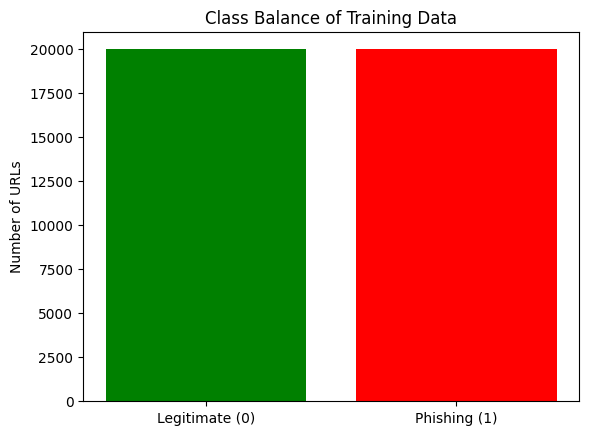

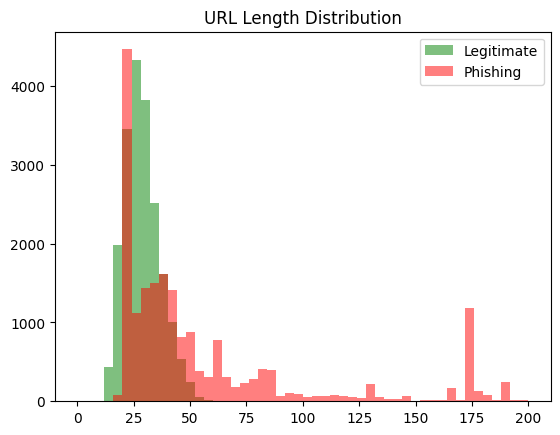

In [8]:
# %pip install matplotlib
import matplotlib.pyplot as plt

# 1. Visualize the Class Balance
# I use 'final_df' because that's what I named it in the previous cell
count_classes = final_df['label'].value_counts()
plt.bar(['Legitimate (0)', 'Phishing (1)'], count_classes, color=['green', 'red'])
plt.title('Class Balance of Training Data')
plt.ylabel('Number of URLs')
plt.show()

# 2. Visualize URL Lengths
# Check lengths using 'final_df'
final_df['length'] = final_df['url'].apply(len)

plt.hist(final_df[final_df['label']==0]['length'], bins=50, alpha=0.5, label='Legitimate', color='green', range=(0, 200))
plt.hist(final_df[final_df['label']==1]['length'], bins=50, alpha=0.5, label='Phishing', color='red', range=(0, 200))
plt.title('URL Length Distribution')
plt.legend()
plt.show()